# EIA Thermoelectric Cooling Data (2014 - 2024)

# `02_profile_analysis.ipynb`

**Author:** Amy Zhang  
**AI Collaborators:** ChatGPT, Claude Code, Perplexity AI  
**Date:** January 2026

## Table of Contents

1. **Import Libraries & Dataset**  
2. **Data Shape: Finding the Observation Grain**  
   ***2a) Investigating Multiple Technology-Type Columns***  
   ***2b) Conclusion: Grain candidate `plant_code`-`generator_id`-`boiler_id`-`cooling_id`-`year`-`month`*** 
3. **Data Profiling & Investigating**  
   ***3a) Investigating the 420-Row Discrepancy***                                                          
      → Discovery: Not duplicates — rows with NULL grain values excluded from groupby()  
   ***3b) Examine water metrics & overall fuel consumption***   
   ***3c) Examine equipment status & relationship type***  
        *3c1) EIA Status Codes Lookup*    
        *3c2) Normalization & Rate Comparison: `*_status` Columns*   
   ***3d) Conclusion: Grain confirmed, incomplete rows are systematic (not noise)***    
5. **Plant-Level Validation & Paradox Resolution**  
   ***4a) Plant-Level Validation***  
        *4a1) Imputation*  
   ***4b) Explore "Paradox Timelines" across the dataset***
6. **Melt dataset: `cooling_df_2`**  
   ***5a) Generating Paradox Timeline Flags***  
   ***5b) Water Metric Derivations***  
7. **Conclusion**

---
# 1. Import Libraries & Dataset

In [1]:
# 1. Auto-reload external modules (during development)
%load_ext autoreload
%autoreload 2

# 2. Standard library
import os
import re

# 3. Third party  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from pathlib import Path


In [2]:
csv_file_path = '../data_exports/sql_ready_data.csv'                          
cooling_df = pd.read_csv(csv_file_path)
print(cooling_df.dtypes.to_string())

/var/folders/0t/y1sp06bd67v24njwrd0_ch980000gn/T/ipykernel_52551/648573769.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  cooling_df = pd.read_csv(csv_file_path)


utility_id                                                                  int64
state                                                                      object
plant_code                                                                  int64
plant_name                                                                 object
year                                                                        int64
month                                                                       int64
generator_id                                                               object
boiler_id                                                                  object
cooling_id                                                                 object
generator_primary_technology                                               object
summer_capacity_of_steam_turbines_mw                                      float64
gross_generation_from_steam_turbines_mwh                                  float64
net_generation_f

---
# 2. Data Shape: Finding the Observation Grain

In [156]:
from scripts.utils import coverage_summary, coverage_heatmap, column_profile, save_df

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/coverage_heatmap_20260124_151640.png


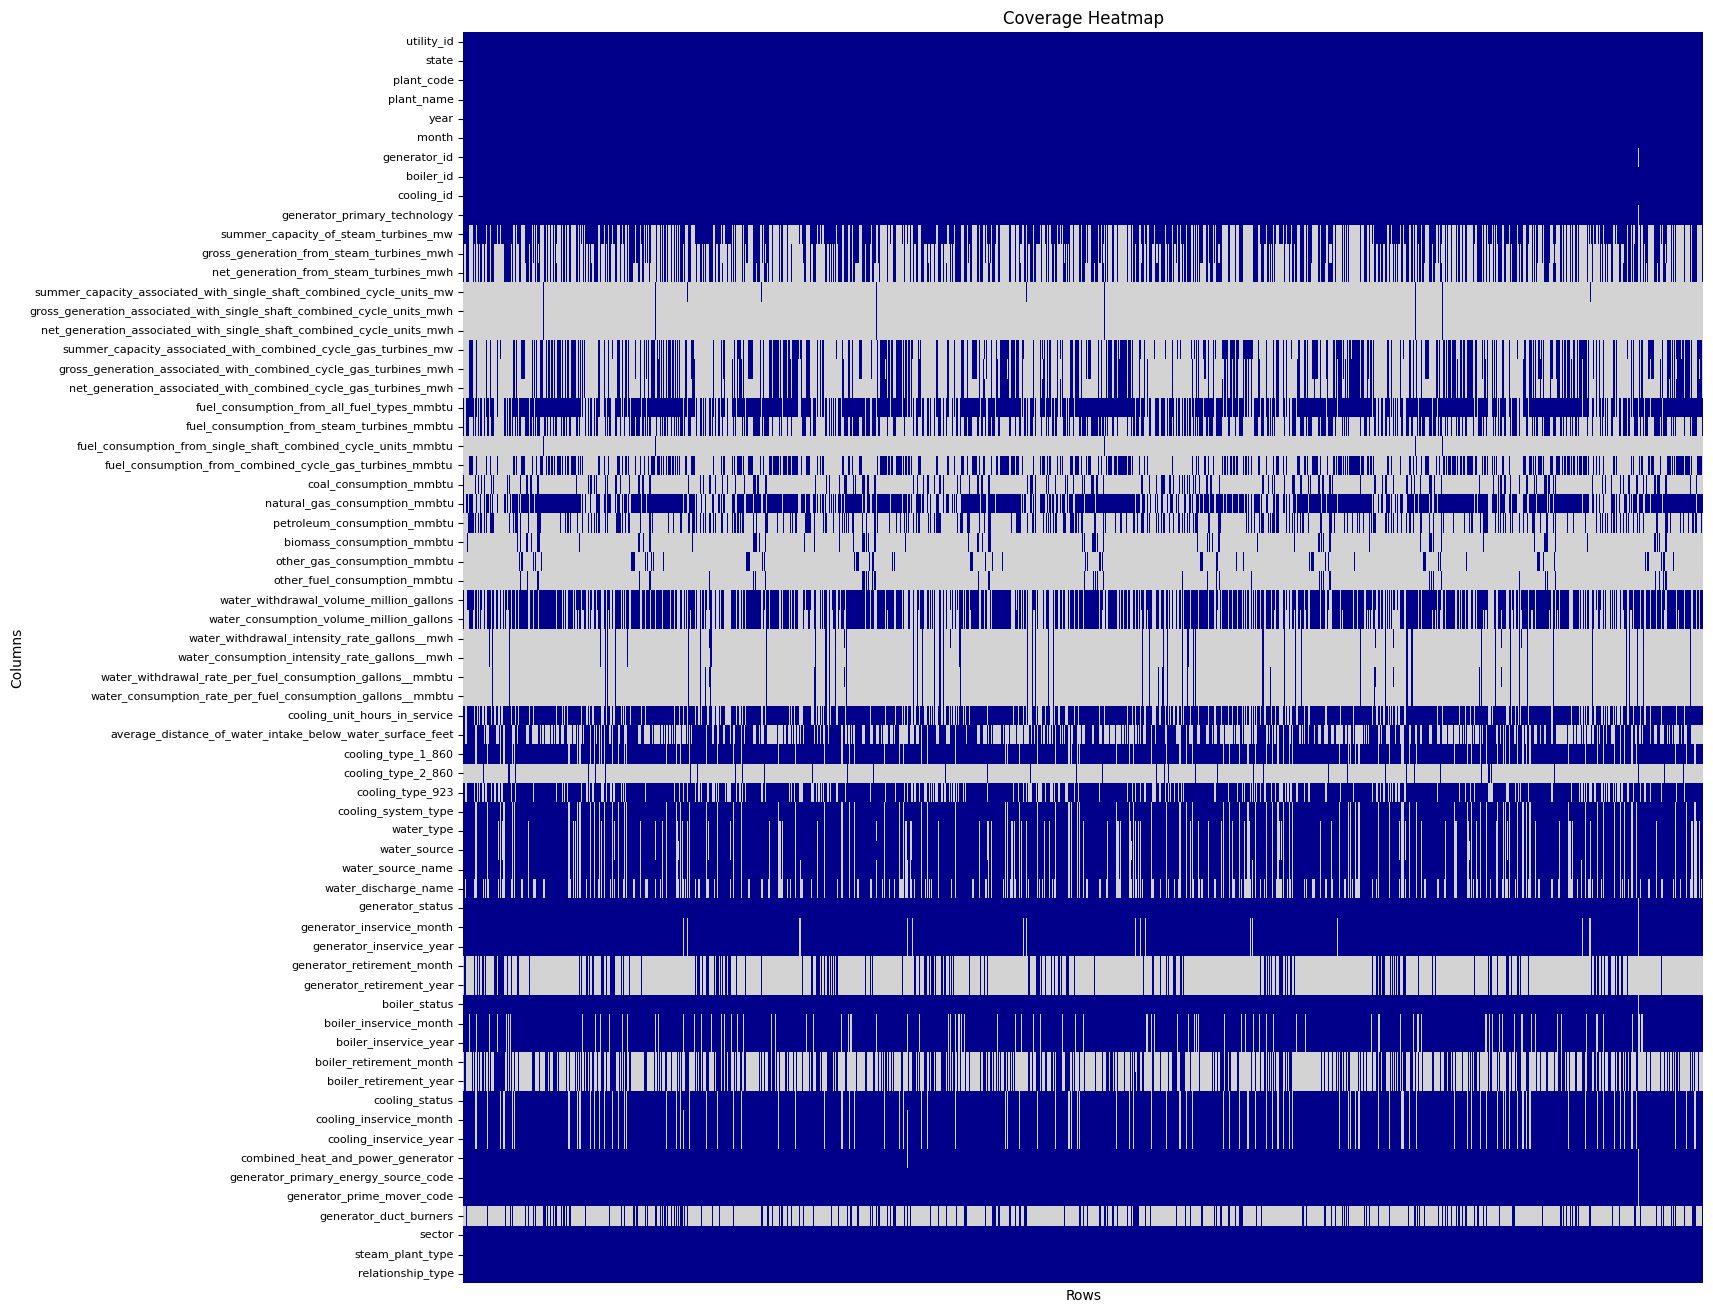

PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/coverage_heatmap_20260124_151640.png')

In [4]:
coverage_heatmap(cooling_df, transpose=True)  

In [5]:
coverage_summary(cooling_df)

,missing_count,missing_%
utility_id,0,0.00
state,24,0.00
plant_code,0,0.00
plant_name,24,0.00
year,0,0.00
month,0,0.00
generator_id,396,0.04
boiler_id,156,0.02
cooling_id,24,0.00
generator_primary_technology,396,0.04


## Notes: 

> See `decision_appendix.ipynb`: '`02_profile_analysis`: ERD Inference from Column Semantics'

## 2a) Investigation of Multiple Technology-Type Columns

In [6]:
# Define the technology column groups                                         
steam_cols = [c for c in cooling_df.columns if 'steam_turbines' in c]          
single_shaft_cols = [c for c in cooling_df.columns if 'single_shaft' in c]    
combined_cycle_cols = [c for c in cooling_df.columns if 'combined_cycle_gas_turbines' in c]                                            
                                                                                
# Check if each row has ANY non-null value in each group                      
has_steam = cooling_df[steam_cols].notna().any(axis=1)                        
has_single_shaft = cooling_df[single_shaft_cols].notna().any(axis=1)          
has_combined_cycle = cooling_df[combined_cycle_cols].notna().any(axis=1)      
                                                                                
# Count how many technology types each row has data for                       
tech_count = has_steam.astype(int) + has_single_shaft.astype(int) + has_combined_cycle.astype(int)                                                
                                                                                
# Key question: do any rows have MORE than one at the same time?                           
print("Rows by technology count:")                                            
print(tech_count.value_counts().sort_index())                                 
                                                                                
print(f"\nRows with multiple technologies: {(tech_count > 1).sum()}")  

Rows by technology count:
0      3930
1    913506
Name: count, dtype: int64

Rows with multiple technologies: 0


In [7]:
# Derive technology_type from the sparse columns                              
cooling_df['technology_type'] = np.select(                                    
    [has_steam, has_single_shaft, has_combined_cycle],                        
    ['steam_turbine', 'single_shaft_combined_cycle','combined_cycle_gas_turbine'], default=None                                                              
)                                                                             
                                                                                
# Verify                                                                      
print(cooling_df['technology_type'].value_counts(dropna=False))

technology_type
steam_turbine                  546285
combined_cycle_gas_turbine     359121
single_shaft_combined_cycle      8100
None                             3930
Name: count, dtype: int64


In [8]:
# Technology types per generator_id                                           
tech_type_per_plant_generator = cooling_df.groupby(['plant_code', 'generator_id'])['technology_type'].nunique()               
                                                                                
print("Technology types per plant_code - generator_id:")                                   
print(tech_type_per_plant_generator.value_counts().sort_index())                    
                                                                                
print(f"\nPlant Generators with multiple tech types: {(tech_type_per_plant_generator > 1).sum()}")

Technology types per plant_code - generator_id:
technology_type
0       5
1    3397
Name: count, dtype: int64

Plant Generators with multiple tech types: 0


In [9]:
# Get the tech-specific fuel consumption value for each row (only one should be non-null)                                                                  
tech_fuel_cols = ['fuel_consumption_from_steam_turbines_mmbtu',
                  'fuel_consumption_from_single_shaft_combined_cycle_units_mmbtu',
                  'fuel_consumption_from_combined_cycle_gas_turbines_mmbtu']                                                                             
                                                                                
# Coalesce: grab whichever tech-specific value exists                         
cooling_df['fuel_consumption_tech_specific'] = cooling_df[tech_fuel_cols].bfill(axis=1).iloc[:, 0]                           
                                                                                
# Compare to 'all'                                                            
all_col = 'fuel_consumption_from_all_fuel_types_mmbtu'                        
                                                                                
# Where both exist, are they equal?                                           
both_exist = cooling_df[all_col].notna() & cooling_df['fuel_consumption_tech_specific'].notna()                          
                                                                                
matches = cooling_df.loc[both_exist, all_col] == cooling_df.loc[both_exist,'fuel_consumption_tech_specific']                                             
                                                                                
print(f"Rows where both exist: {both_exist.sum()}")                           
print(f"Rows where they match: {matches.sum()}")                              
print(f"Rows where they differ: {(~matches).sum()}")

Rows where both exist: 723160
Rows where they match: 723160
Rows where they differ: 0


In [10]:
cooling_df[['fuel_consumption_from_all_fuel_types_mmbtu',
            'fuel_consumption_from_steam_turbines_mmbtu',
            'fuel_consumption_from_single_shaft_combined_cycle_units_mmbtu',
            'fuel_consumption_from_combined_cycle_gas_turbines_mmbtu']].drop_duplicates().head(50)

,fuel_consumption_from_all_fuel_types_mmbtu,fuel_consumption_from_steam_turbines_mmbtu,fuel_consumption_from_single_shaft_combined_cycle_units_mmbtu,fuel_consumption_from_combined_cycle_gas_turbines_mmbtu
0,NaN,NaN,NaN,NaN
36,0.0,0.0,NaN,NaN
40,82984.0,82984.0,NaN,NaN
41,291447.0,291447.0,NaN,NaN
42,138617.0,138617.0,NaN,NaN
46,52591.0,52591.0,NaN,NaN
47,151077.0,151077.0,NaN,NaN
50,163.0,163.0,NaN,NaN
52,118787.0,118787.0,NaN,NaN
53,316808.0,316808.0,NaN,NaN


In [11]:
# 1. Does each (plant_code, cooling_id) have one cooling_system_type?         
cooling_type_per_system = cooling_df.groupby(['plant_code','cooling_id'])['cooling_system_type'].nunique()                               
print("Cooling system types per (plant_code, cooling_id):")                   
print(cooling_type_per_system.value_counts().sort_index())

Cooling system types per (plant_code, cooling_id):
cooling_system_type
0     110
1    1950
2      46
3       1
Name: count, dtype: int64


In [12]:
# 2. Does each (plant_code, generator_id, boiler_id, cooling_id) have one relationship_type?                                                            
rel_per_combo = cooling_df.groupby(['plant_code', 'generator_id', 'boiler_id', 'cooling_id'])['relationship_type'].nunique()                                              
print("\nRelationship types per (plant, gen, boiler, cooling):")              
print(rel_per_combo.value_counts().sort_index())


Relationship types per (plant, gen, boiler, cooling):
relationship_type
1    5965
2    1449
3      55
4       4
Name: count, dtype: int64


In [13]:
# 3. The grain test - does adding year/month get us to row count?             
print("\nGrain hunt:")                                                        
print(f"Total rows: {len(cooling_df)}")                                       
print(f"(plant, gen, boiler, cooling): {cooling_df.groupby(['plant_code','generator_id', 'boiler_id', 'cooling_id']).ngroups}")                        
print(f"(plant, gen, boiler, cooling, year, month):{cooling_df.groupby(['plant_code', 'generator_id', 'boiler_id', 
                                                                        'cooling_id','year', 'month']).ngroups}")
print(f"(plant, gen, boiler, cooling, relationship_type, year, month):{cooling_df.groupby(['plant_code', 'generator_id', 'boiler_id', 
                                                                        'cooling_id', 'relationship_type', 'year', 'month']).ngroups}")


Grain hunt:
Total rows: 917436
(plant, gen, boiler, cooling): 7473
(plant, gen, boiler, cooling, year, month):917016
(plant, gen, boiler, cooling, relationship_type, year, month):917016


## 2b) Conclusion: Grain candidate `plant_code`-`generator_id`-`boiler_id`-`cooling_id`-`year`-`month`

---
# 3. Data Profiling & Cleaning

## 3a) Investigating the 420-Row Discrepancy
> According to our discovered candidate, there are 420 rows that contain duplicates of the composite grain. 

In [14]:
# Find the composite keys that appear more than once                          
grain_cols = ['plant_code', 'generator_id', 'boiler_id', 'cooling_id', 'year','month']                                                                     
                                                                                
dupe_counts = cooling_df.groupby(grain_cols).size()                           
dupes = dupe_counts[dupe_counts > 1]                                          
                                                                                
print(f"Duplicate grain combinations: {len(dupes)}")                          
print(f"Total extra rows: {dupes.sum() - len(dupes)}")  # Should be ~420      
print()                                                                       
print("Duplication counts:")                                                  
print(dupes.value_counts().sort_index()) 

Duplicate grain combinations: 0
Total extra rows: 0

Duplication counts:
Series([], Name: count, dtype: int64)


In [15]:
# Check for NULLs in grain columns                                            
print("NULLs in grain columns:")                                              
print(cooling_df[grain_cols].isnull().sum())                                  
                                                                                
# How many rows have at least one NULL in the grain?                          
rows_with_null_grain = cooling_df[grain_cols].isnull().any(axis=1).sum()      
print(f"\nRows with NULL in at least one grain column: {rows_with_null_grain}")

NULLs in grain columns:
plant_code        0
generator_id    396
boiler_id       156
cooling_id       24
year              0
month             0
dtype: int64

Rows with NULL in at least one grain column: 420


In [131]:
count = null_grain[
    null_grain[['generator_id', 'boiler_id', 'cooling_id']].isna().all(axis=1)
].shape[0]

count

0

## 3b) Examine water metrics & overall fuel consumption
> Do these rows contain meaningful information for analysis? If not, can they be removed? 

In [16]:
# Isolate the 420 rows with NULL grain                                        
grain_cols = ['plant_code', 'generator_id', 'boiler_id', 'cooling_id', 'year','month']                                                                     
null_grain = cooling_df[cooling_df[grain_cols].isnull().any(axis=1)]          

# 1) Water metrics + fuel consumption — are these rows useful?
metric_cols = [
    'water_withdrawal_volume_million_gallons',
    'water_consumption_volume_million_gallons',
    'fuel_consumption_from_all_fuel_types_mmbtu'
]

print("=== Q1: Metrics coverage in NULL-grain rows ===")
# Counts
counts = null_grain[metric_cols].notna().sum()
# Percentages
percent = null_grain[metric_cols].notna().mean() * 100

for col in metric_cols:
    print(f"{col}: {counts[col]} rows ({percent[col]:.1f}%)")

print("\n=== Q1: Metrics coverage in full dataset ===")
counts_full = cooling_df[metric_cols].notna().sum()
percent_full = cooling_df[metric_cols].notna().mean() * 100

for col in metric_cols:
    print(f"{col}: {counts_full[col]} rows ({percent_full[col]:.1f}%)")


=== Q1: Metrics coverage in NULL-grain rows ===
water_withdrawal_volume_million_gallons: 216 rows (51.4%)
water_consumption_volume_million_gallons: 216 rows (51.4%)
fuel_consumption_from_all_fuel_types_mmbtu: 24 rows (5.7%)

=== Q1: Metrics coverage in full dataset ===
water_withdrawal_volume_million_gallons: 606172 rows (66.1%)
water_consumption_volume_million_gallons: 567951 rows (61.9%)
fuel_consumption_from_all_fuel_types_mmbtu: 724004 rows (78.9%)


In [17]:
null_grain[metric_cols].describe()

,water_withdrawal_volume_million_gallons,water_consumption_volume_million_gallons,fuel_consumption_from_all_fuel_types_mmbtu
count,216.000000,216.000000,24.000000
mean,7439.986759,0.009259,109151.833333
std,2243.060441,0.096001,119764.531672
min,332.800000,0.000000,0.000000
25%,6465.052250,0.000000,0.000000
50%,7560.050000,0.000000,32592.500000
75%,8489.278000,0.000000,216643.750000
max,11509.400000,1.000000,311270.000000


#### Create & Save Plots

✅ Saved: ../visualizations/metric_distributions_missing_identifiers.png


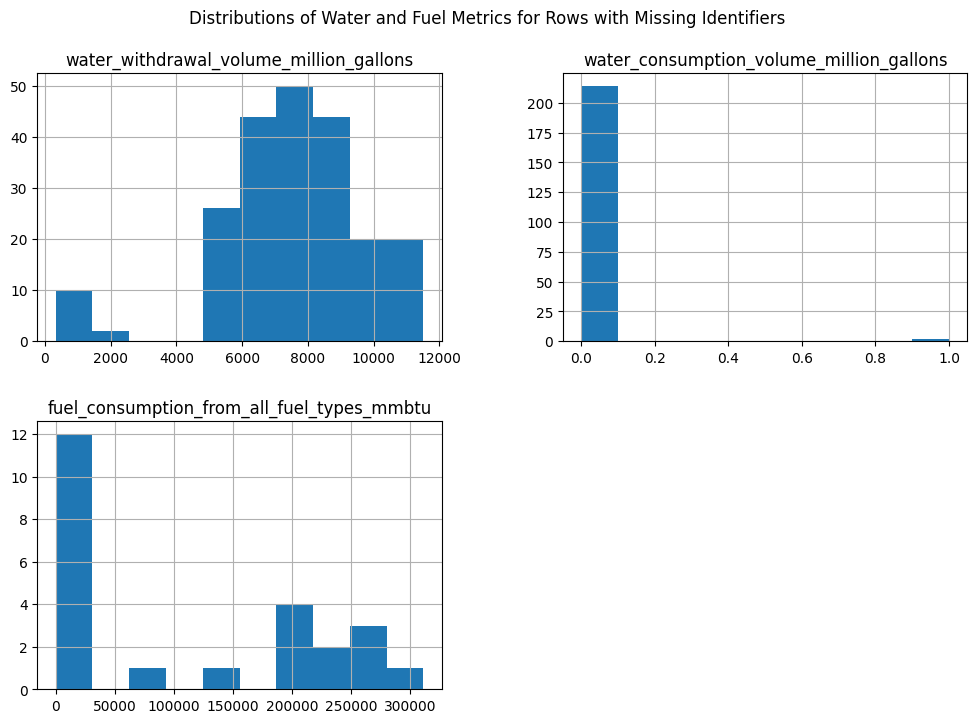

In [18]:
fig = null_grain[metric_cols].hist(figsize=(12,8))
plt.suptitle("Distributions of Water and Fuel Metrics for Rows with Missing Identifiers", y=0.96)
fig = plt.gcf()  # get current figure

save_dir = Path("../visualizations")
save_dir.mkdir(exist_ok=True)

filename = "metric_distributions_missing_identifiers.png"
save_path = save_dir / filename

fig.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"✅ Saved: {save_path}")


## 3c) Examine equipment status & relationship type for duplicate rows

> Are these 420 rows systematically different, or just incomplete versions of normal rows?

In [19]:
# 2) Status and relationship_type — are these special cases?                  
print("=== Q2: Status & relationship_type ===")                                                                                 
print(null_grain['relationship_type'].value_counts(dropna=False))             
print()                                                                                                                          
print(null_grain['generator_status'].value_counts(dropna=False))              
print()
print(null_grain['boiler_status'].value_counts(dropna=False))
print()
print(null_grain['cooling_status'].value_counts(dropna=False))                

=== Q2: Status & relationship_type ===
relationship_type
Unoperable    420
Name: count, dtype: int64

generator_status
NaN    396
OP      24
Name: count, dtype: int64

boiler_status
NaN    372
CN      24
OP      24
Name: count, dtype: int64

cooling_status
OP     228
PL      96
CN      48
CO      24
NaN     24
Name: count, dtype: int64


In [20]:
cooling_df['relationship_type'].value_counts(dropna=False)

relationship_type
1C MB MG      391740
Complex       228806
Unoperable    174635
Simple         80981
1C 1B MG       28610
1C MB 1G        7250
MC 1B MG        2868
MC 1B 1G        1946
MC MB 1G         600
Name: count, dtype: int64

### 3c.1) EIA Status Codes Lookup

In [21]:
# Get unique values for each status column                                    
gen_status = set(cooling_df['generator_status'].dropna().unique())            
boiler_status = set(cooling_df['boiler_status'].dropna().unique())            
cooling_status = set(cooling_df['cooling_status'].dropna().unique())          
                                                                                
# All unique values across all three                                          
all_values = gen_status | boiler_status | cooling_status                      
                                                                                
# Build comparison table                                                      
comparison = pd.DataFrame({                                                   
    'value': sorted(all_values),                                              
    'generator': [v in gen_status for v in sorted(all_values)],               
    'boiler': [v in boiler_status for v in sorted(all_values)],               
    'cooling': [v in cooling_status for v in sorted(all_values)]              
})

comparison

,value,generator,boiler,cooling
0,CN,True,True,True
1,CO,False,True,True
2,IP,True,False,False
3,L,True,False,False
4,OA,True,False,False
5,OP,True,True,True
6,OS,True,True,True
7,P,True,False,False
8,PL,False,True,True
9,R,False,True,False


In [22]:
cooling_df['boiler_status'] = cooling_df['boiler_status'].str.upper()

### 3c.2) Normalization & Rate Comparison: `*_status` Columns

In [23]:
def compare_distributions(df_a, df_b, column, label_a="group_a",              
label_b="group_b"):                                                           
    """Compare value distributions between two subsets"""                     
    dist_a = df_a[column].value_counts(dropna=False,                          
normalize=True).mul(100).round(1)                                             
    dist_b = df_b[column].value_counts(dropna=False,                          
normalize=True).mul(100).round(1)                                             
                                                                                
    comparison = pd.DataFrame({                                               
        f'{label_a}_pct': dist_a,                                             
        f'{label_b}_pct': dist_b                                              
    }).fillna(0)                                                              
    comparison['diff'] = (comparison[f'{label_a}_pct'] -                      
comparison[f'{label_b}_pct']).round(1)                                        
    return comparison                                                         
                                                                                
# Define the two Unoperable subsets                                           
unoperable_null = null_grain  # Already all Unoperable                        
unoperable_complete = cooling_df[                                             
    (cooling_df['relationship_type'] == 'Unoperable') &                       
    (cooling_df[['generator_id', 'boiler_id',                                 
'cooling_id']].notna().all(axis=1))                                           
]                                                                             
                                                                                
print(f"Unoperable NULL grain: {len(unoperable_null)}")                       
print(f"Unoperable complete grain: {len(unoperable_complete)}")               
print()                                                                       
                                                                                
# Compare key columns                                                         
for col in ['generator_status', 'boiler_status', 'cooling_status',            
'cooling_system_type']:                                                       
    print(f"=== {col}: Unoperable NULL vs Unoperable Complete ===")           
    print(compare_distributions(                                              
        unoperable_null,                                                      
        unoperable_complete,                                                  
        col,                                                                  
        label_a="null_grain",                                                 
        label_b="complete_grain"                                              
    ))                                                                        
    print()

Unoperable NULL grain: 420
Unoperable complete grain: 174215

=== generator_status: Unoperable NULL vs Unoperable Complete ===
                  null_grain_pct  complete_grain_pct  diff
generator_status                                          
CN                           0.0                 0.6  -0.6
IP                           0.0                 0.7  -0.7
L                            0.0                 0.6  -0.6
OA                           0.0                 0.1  -0.1
OP                           5.7                11.3  -5.6
OS                           0.0                 0.2  -0.2
P                            0.0                 0.6  -0.6
RE                           0.0                81.1 -81.1
SB                           0.0                 0.0   0.0
T                            0.0                 0.4  -0.4
TS                           0.0                 0.6  -0.6
U                            0.0                 1.7  -1.7
V                            0.0               

In [24]:
cooling_df['cooling_system_type'].value_counts(dropna=False)

cooling_system_type
Closed        541566
Open          232416
NaN            76896
Dry/Hybrid     53640
Other          12918
Name: count, dtype: int64

---
# 4. Plant-Level Validation & Paradox Resolution

## 4a) Plant-Level Validation

In [25]:
# Boolean overlap check
missing_state = cooling_df['state'].isna()
missing_plant = cooling_df['plant_name'].isna()

# How many rows have both missing?
(missing_state & missing_plant).sum()


np.int64(24)

In [26]:
with pd.option_context('display.max_columns', None):
    print(cooling_df.loc[missing_state & missing_plant].head(24))

        utility_id state  plant_code plant_name  year  month generator_id  \
247284       58371   NaN       57273        NaN  2015      1          NaN   
247285       58371   NaN       57273        NaN  2015      2          NaN   
247286       58371   NaN       57273        NaN  2015      3          NaN   
247287       58371   NaN       57273        NaN  2015      4          NaN   
247288       58371   NaN       57273        NaN  2015      5          NaN   
247289       58371   NaN       57273        NaN  2015      6          NaN   
247290       58371   NaN       57273        NaN  2015      7          NaN   
247291       58371   NaN       57273        NaN  2015      8          NaN   
247292       58371   NaN       57273        NaN  2015      9          NaN   
247293       58371   NaN       57273        NaN  2015     10          NaN   
247294       58371   NaN       57273        NaN  2015     11          NaN   
247295       58371   NaN       57273        NaN  2015     12          NaN   

In [27]:
cooling_df['technology_type'].value_counts(dropna=False)

technology_type
steam_turbine                  546285
combined_cycle_gas_turbine     359121
single_shaft_combined_cycle      8100
None                             3930
Name: count, dtype: int64

### 1. Can we infer `plant_name` and/or `state` based on `plant_code` and `utility_id`

In [28]:
# Check if this plant exists elsewhere with name/state
plant_matches = cooling_df[
    (cooling_df['plant_code'] == 57273) & 
    (cooling_df['utility_id'] == 58371)
][['plant_code', 'plant_name', 'state']].drop_duplicates()

print(plant_matches)


        plant_code                  plant_name state
247284       57273                         NaN   NaN
582576       57273  Blythe Solar Power Project    CA


### 2. Explore 'fingerprint' for 'Blythe Solar Power Project' in California

In [29]:
# Create a subset dataset focusing on just Blythe Solar Power Project in CA
blythe = cooling_df.loc[
    (cooling_df['plant_name'] == 'Blythe Solar Power Project') &
    (cooling_df['state'] == 'CA')
].copy()

In [30]:
blythe.shape

(96, 67)

In [31]:
# Earliest to latest observation date
obs_dates = pd.to_datetime(
    dict(
        year=blythe['year'],
        month=blythe['month'],
        day=1
    ),
    errors='coerce'
)

obs_dates.min(), obs_dates.max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2014-12-01 00:00:00'))

In [32]:
blythe.groupby(['generator_id', 'boiler_id', 'cooling_id']).size().reset_index(name='row_count')

,generator_id,boiler_id,cooling_id,row_count
0,1,A,1,12
1,1,B,1,12
2,2,A,1,12
3,2,B,1,12
4,3,A,1,12
5,3,B,1,12
6,4,A,1,12
7,4,B,1,12


In [33]:
# Define component-status pairs
components = [
    ('generator_id', 'generator_status'),
    ('boiler_id', 'boiler_status'),
    ('cooling_id', 'cooling_status')
]

for comp_id, comp_status in components:
    print(f"\n--- {comp_id} ---")
    print(blythe.groupby(comp_id)[comp_status].value_counts(dropna=False).reset_index(name='row_count'))


--- generator_id ---
  generator_id generator_status  row_count
0            1               IP         24
1            2               IP         24
2            3               IP         24
3            4               IP         24

--- boiler_id ---
  boiler_id boiler_status  row_count
0         A            CN         48
1         B            CN         48

--- cooling_id ---
  cooling_id cooling_status  row_count
0          1             CN         96


In [34]:
num_summary, cat_summary = column_profile(blythe)
num_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
utility_id,96.0,58371.0,0.000000,58371.0,58371.00,58371.0,58371.00,58371.0,0,0.0
plant_code,96.0,57273.0,0.000000,57273.0,57273.00,57273.0,57273.00,57273.0,0,0.0
year,96.0,2014.0,0.000000,2014.0,2014.00,2014.0,2014.00,2014.0,0,0.0
month,96.0,6.5,3.470174,1.0,3.75,6.5,9.25,12.0,0,0.0
summer_capacity_of_steam_turbines_mw,48.0,232.0,0.000000,232.0,232.00,232.0,232.00,232.0,48,50.0
gross_generation_from_steam_turbines_mwh,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,100.0
net_generation_from_steam_turbines_mwh,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,100.0
summer_capacity_associated_with_single_shaft_combined_cycle_units_mw,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,100.0
gross_generation_associated_with_single_shaft_combined_cycle_units_mwh,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,100.0
net_generation_associated_with_single_shaft_combined_cycle_units_mwh,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,100.0


In [35]:
cat_summary

,unique_count,mode,mode_count,mode_pct,missing_count,missing_pct
column,,,,,,
state,1,CA,96,100.0,0,0.0
plant_name,1,Blythe Solar Power Project,96,100.0,0,0.0
generator_id,4,1,24,25.0,0,0.0
boiler_id,2,A,48,50.0,0,0.0
cooling_id,1,1,96,100.0,0,0.0
generator_primary_technology,1,Solar Thermal without Energy Storage,96,100.0,0,0.0
cooling_type_1_860,1,NaN,96,100.0,96,100.0
cooling_type_2_860,1,NaN,96,100.0,96,100.0
cooling_type_923,1,NaN,96,100.0,96,100.0


### 4a1) Imputation 

In [36]:
# Impute missing plant_name and state for Blythe Solar (plant_code 57273)
mask = (cooling_df['plant_code'] == 57273) & (cooling_df['plant_name'].isna())
rows_before = mask.sum()

# Impute both columns in one go
cooling_df.loc[mask, ['plant_name', 'state']] = ['Blythe Solar Power Project', 'CA']

# Verify
print(f"Rows imputed: {rows_before} → {cooling_df.loc[mask, 'plant_name'].isna().sum()} missing")
print(cooling_df[cooling_df['plant_code'] == 57273][['plant_code', 'plant_name', 'state']].drop_duplicates())

Rows imputed: 24 → 0 missing
        plant_code                  plant_name state
247284       57273  Blythe Solar Power Project    CA


## 4b) Explore "Paradox Timelines" across the dataset

### 1. Create `cooling_subset`: subset of rows with at least one `*_inservice_` month/year

In [49]:
# Define boolean masks for each equipment
gen_mask = cooling_df['generator_inservice_year'].notna() & cooling_df['generator_inservice_month'].notna()
boiler_mask = cooling_df['boiler_inservice_year'].notna() & cooling_df['boiler_inservice_month'].notna()
cooling_mask = cooling_df['cooling_inservice_year'].notna() & cooling_df['cooling_inservice_month'].notna()

# Combine masks: keep row if any equipment has valid in-service info
any_inservice_mask = gen_mask | boiler_mask | cooling_mask

# Subset dataframe
cooling_subset = cooling_df[any_inservice_mask].copy()

print(f"Rows with at least one in-service month/year: {len(cooling_subset):,}")


Rows with at least one in-service month/year: 916,332


In [67]:
cooling_df.shape

(917436, 67)

### 2. Enrich `cooling_subset`: convert `year`/`month` and available `*_inservice_` year/month to datetime (+4 columns)

In [50]:
# Observation datetime from year and month columns
cooling_subset['observation_date'] = pd.to_datetime(
    dict(
        year=cooling_subset['year'].astype(int),
        month=cooling_subset['month'].astype(int),
        day=1
    ),
    errors='coerce'
)

# Inservice dates per equipment (only where data exists)
for equip in ['generator', 'boiler', 'cooling']:
    year_col = f'{equip}_inservice_year'
    month_col = f'{equip}_inservice_month'
    date_col = f'{equip}_inservice_date'
    
    valid_mask = cooling_subset[year_col].notna() & cooling_subset[month_col].notna()
    paradox_count = valid_mask.sum()
    
    if paradox_count > 0:  # Only process if data exists
        cooling_subset.loc[valid_mask, date_col] = pd.to_datetime(
            dict(
                year=cooling_subset.loc[valid_mask, year_col].astype(int),
                month=cooling_subset.loc[valid_mask, month_col].astype(int),
                day=1
            ),
            errors='coerce'
        )
        print(f"{equip}: Created {paradox_count:,} {date_col} values")


generator: Created 904,356 generator_inservice_date values
boiler: Created 851,700 boiler_inservice_date values
cooling: Created 838,728 cooling_inservice_date values


In [54]:
# Compute paradox flags directly on the full dataset
for equip in ['generator', 'boiler', 'cooling']:
    date_col = f'{equip}_inservice_date'
    flag_col = f'{equip}_paradox_flag'
    
    cooling_subset[flag_col] = cooling_subset[date_col] > cooling_subset['observation_date']

In [58]:
save_df(cooling_subset, 'cooling_subset_with_date_paradox_flags.csv')

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_subset_with_date_paradox_flags.csv


PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_subset_with_date_paradox_flags.csv')

### 3. Create `master_paradox`: subset of `cooling_subset` containing only rows with timeline paradox
(i.e. `*_inservice_` date > `observation_date`)

In [59]:
# Master paradox dataframe: rows with a paradox in any equipment
master_paradox = cooling_subset[
    cooling_subset[['generator_paradox_flag', 'boiler_paradox_flag', 'cooling_paradox_flag']].any(axis=1)
].copy()

# Quick summary
print(f"Total paradox rows across all equipment: {len(master_paradox):,}")

# View first few columns
master_paradox[['plant_code', 'plant_name', 'state',
                'generator_inservice_date', 'boiler_inservice_date', 'cooling_inservice_date',
                'observation_date',
                'generator_paradox_flag', 'boiler_paradox_flag', 'cooling_paradox_flag']].head()

Total paradox rows across all equipment: 15,017


,plant_code,plant_name,state,generator_inservice_date,boiler_inservice_date,cooling_inservice_date,observation_date,generator_paradox_flag,boiler_paradox_flag,cooling_paradox_flag
12,3,Barry,AL,NaT,2023-11-01,2023-11-01,2022-01-01,False,True,True
13,3,Barry,AL,NaT,2023-11-01,2023-11-01,2022-02-01,False,True,True
14,3,Barry,AL,NaT,2023-11-01,2023-11-01,2022-03-01,False,True,True
15,3,Barry,AL,NaT,2023-11-01,2023-11-01,2022-04-01,False,True,True
16,3,Barry,AL,NaT,2023-11-01,2023-11-01,2022-05-01,False,True,True


In [77]:
master_paradox['plant_code'].nunique()

117

In [78]:
cooling_df['plant_code'].nunique()

1021

In [60]:
save_df(master_paradox, 'cooling_subset_just_paradoxes.csv')

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_subset_just_paradoxes.csv


PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_subset_just_paradoxes.csv')

### 4. Explore `master_paradox`:

In [64]:
num_summary, cat_summary = column_profile(master_paradox)                                                  

In [65]:
cat_summary

,unique_count,mode,mode_count,mode_pct,missing_count,missing_pct
column,,,,,,
state,35,PA,2055,13.68,0,0.00
plant_name,118,St Joseph Energy Center,1602,10.67,0,0.00
generator_id,168,CT1,778,5.18,147,0.98
boiler_id,101,HRSG1,2924,19.47,135,0.90
cooling_id,90,ACC1,1129,7.52,0,0.00
generator_primary_technology,9,Natural Gas Fired Combined Cycle,13862,92.31,147,0.98
cooling_type_1_860,9,(RI) Recirculate: Induced Draft,8796,58.57,435,2.90
cooling_type_2_860,3,NaN,14964,99.65,14964,99.65
cooling_type_923,8,NaN,12444,82.87,12444,82.87


In [66]:
num_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
utility_id,15017.0,40703.656456,23003.272928,189.0,15466.000,56641.000,58889.000,65835.00,0,0.00
plant_code,15017.0,49076.963841,21200.905188,3.0,55641.000,57794.000,60138.000,66918.00,0,0.00
year,15017.0,2017.669974,2.613314,2014.0,2015.000,2018.000,2020.000,2024.00,0,0.00
month,15017.0,6.081974,3.441130,1.0,3.000,6.000,9.000,12.00,0,0.00
summer_capacity_of_steam_turbines_mw,5877.0,302.683580,250.978493,8.4,143.300,245.000,345.000,1212.00,9140,60.86
gross_generation_from_steam_turbines_mwh,618.0,64365.593851,67454.325167,0.0,7159.500,26882.000,136647.000,312565.00,14399,95.88
net_generation_from_steam_turbines_mwh,618.0,63471.624595,67045.256874,-4401.0,6320.250,23892.000,136647.000,264021.00,14399,95.88
summer_capacity_associated_with_single_shaft_combined_cycle_units_mw,1044.0,527.047893,64.909182,378.0,480.000,520.000,600.000,621.00,13973,93.05
gross_generation_associated_with_single_shaft_combined_cycle_units_mwh,2.0,45850.500000,64842.398942,0.0,22925.250,45850.500,68775.750,91701.00,15015,99.99
net_generation_associated_with_single_shaft_combined_cycle_units_mwh,2.0,44827.500000,63395.658467,0.0,22413.750,44827.500,67241.250,89655.00,15015,99.99


---
# 5. Melt dataset: `cooling_df_2`

In [98]:
# Define the technology types
techs = ['steam_turbine', 'single_shaft_combined_cycle', 'combined_cycle_gas_turbine']

# Helper function: melt tech-specific columns into one unified numeric column
def melt_tech_column(df, tech_col, techs, source_cols, new_col):
    """
    Create a unified column based on technology type.

    Parameters:
    - df: pandas DataFrame
    - tech_col: column indicating technology type
    - techs: list of technology type strings, order matches source_cols
    - source_cols: list of source columns corresponding to each tech
    - new_col: name of the new column to create
    """
    # Cast all source columns to float to avoid dtype conflicts with np.nan
    df[new_col] = np.select(
        [df[tech_col] == t for t in techs],
        [df[col].astype(float) for col in source_cols],
        default=np.nan
    )
    return df

# Mapping of unified columns to their tech-specific source columns
metrics_map = {
    'summer_capacity_mw': [
        'summer_capacity_of_steam_turbines_mw',
        'summer_capacity_associated_with_single_shaft_combined_cycle_units_mw',
        'summer_capacity_associated_with_combined_cycle_gas_turbines_mw'
    ],
    'gross_generation_mwh': [
        'gross_generation_from_steam_turbines_mwh',
        'gross_generation_associated_with_single_shaft_combined_cycle_units_mwh',
        'gross_generation_associated_with_combined_cycle_gas_turbines_mwh'
    ],
    'net_generation_mwh': [
        'net_generation_from_steam_turbines_mwh',
        'net_generation_associated_with_single_shaft_combined_cycle_units_mwh',
        'net_generation_associated_with_combined_cycle_gas_turbines_mwh'
    ],
    'fuel_consumption_mmbtu': [
        'fuel_consumption_from_steam_turbines_mmbtu',
        'fuel_consumption_from_single_shaft_combined_cycle_units_mmbtu',
        'fuel_consumption_from_combined_cycle_gas_turbines_mmbtu'
    ]
}

# Make a copy first
cooling_df_2 = cooling_df.copy()

# Apply helper to the copy
for new_col, source_cols in metrics_map.items():
    cooling_df_2 = melt_tech_column(cooling_df_2, 'technology_type', techs, source_cols, new_col)

# Quick check
cooling_df_2[['technology_type', 'summer_capacity_mw', 'gross_generation_mwh',
              'net_generation_mwh', 'fuel_consumption_mmbtu']].head(10)


,technology_type,summer_capacity_mw,gross_generation_mwh,net_generation_mwh,fuel_consumption_mmbtu
0,steam_turbine,249.0,NaN,NaN,NaN
1,steam_turbine,249.0,NaN,NaN,NaN
2,steam_turbine,249.0,NaN,NaN,NaN
3,steam_turbine,249.0,NaN,NaN,NaN
4,steam_turbine,249.0,NaN,NaN,NaN
5,steam_turbine,249.0,NaN,NaN,NaN
6,steam_turbine,249.0,NaN,NaN,NaN
7,steam_turbine,249.0,NaN,NaN,NaN
8,steam_turbine,249.0,NaN,NaN,NaN
9,steam_turbine,249.0,NaN,NaN,NaN


In [100]:
# List all the tech-specific source columns we no longer need
columns_to_drop = [
    # Summer capacity
    'summer_capacity_of_steam_turbines_mw',
    'summer_capacity_associated_with_single_shaft_combined_cycle_units_mw',
    'summer_capacity_associated_with_combined_cycle_gas_turbines_mw',
    # Gross generation
    'gross_generation_from_steam_turbines_mwh',
    'gross_generation_associated_with_single_shaft_combined_cycle_units_mwh',
    'gross_generation_associated_with_combined_cycle_gas_turbines_mwh',
    # Net generation
    'net_generation_from_steam_turbines_mwh',
    'net_generation_associated_with_single_shaft_combined_cycle_units_mwh',
    'net_generation_associated_with_combined_cycle_gas_turbines_mwh',
    # Fuel consumption
    'fuel_consumption_from_steam_turbines_mmbtu',
    'fuel_consumption_from_single_shaft_combined_cycle_units_mmbtu',
    'fuel_consumption_from_combined_cycle_gas_turbines_mmbtu'
]

# Drop the columns from cooling_df_2
cooling_df_2 = cooling_df_2.drop(columns=columns_to_drop)

# Quick check that they’re gone
print(cooling_df_2.columns)


Index(['utility_id', 'state', 'plant_code', 'plant_name', 'year', 'month',
       'generator_id', 'boiler_id', 'cooling_id',
       'generator_primary_technology',
       'fuel_consumption_from_all_fuel_types_mmbtu', 'coal_consumption_mmbtu',
       'natural_gas_consumption_mmbtu', 'petroleum_consumption_mmbtu',
       'biomass_consumption_mmbtu', 'other_gas_consumption_mmbtu',
       'other_fuel_consumption_mmbtu',
       'water_withdrawal_volume_million_gallons',
       'water_consumption_volume_million_gallons',
       'water_withdrawal_intensity_rate_gallons__mwh',
       'water_consumption_intensity_rate_gallons__mwh',
       'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu',
       'water_consumption_rate_per_fuel_consumption_gallons__mmbtu',
       'cooling_unit_hours_in_service',
       'average_distance_of_water_intake_below_water_surface_feet',
       'cooling_type_1_860', 'cooling_type_2_860', 'cooling_type_923',
       'cooling_system_type', 'water_type', 'water_s

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/coverage_heatmap_20260125_165801.png


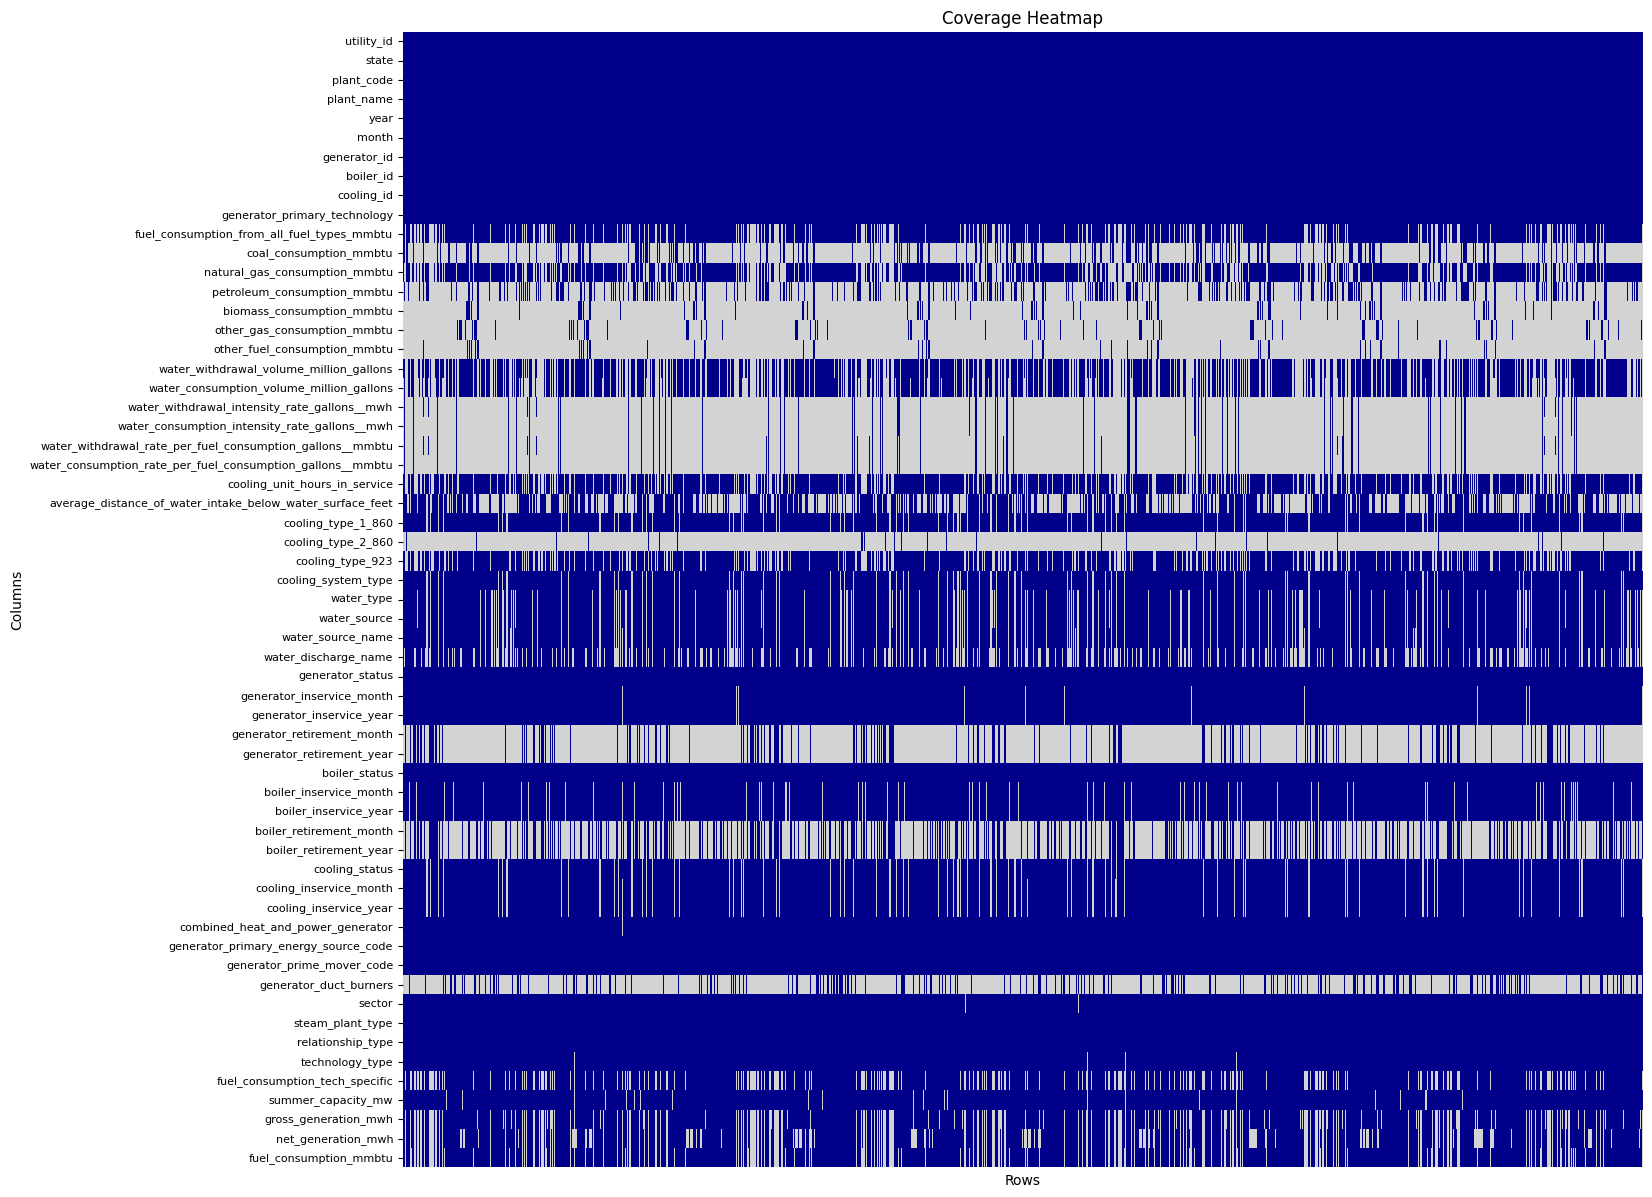

PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/visualizations/coverage_heatmap_20260125_165801.png')

In [101]:
coverage_heatmap(cooling_df_2, transpose=True)  

In [102]:
cooling_df_2.shape

(917436, 59)

In [110]:
coverage_summary(cooling_df_2)

,missing_count,missing_%
utility_id,0,0.00
state,0,0.00
plant_code,0,0.00
plant_name,0,0.00
year,0,0.00
month,0,0.00
generator_id,396,0.04
boiler_id,156,0.02
cooling_id,24,0.00
generator_primary_technology,396,0.04


In [111]:
with pd.option_context('display.max_columns', None):
    print(cooling_df_2.sample(n=5))

        utility_id state  plant_code                        plant_name  year  \
826940       19876    VA       55939                     Warren County  2016   
252            195    AL           8                            Gorgas  2022   
795891        6541    TX       10554       Formosa Utility Venture Ltd  2016   
118829        6455    FL        7302              Hines Energy Complex  2023   
543746       21970    MA       10307  Bellingham Cogeneration Facility  2014   

        month generator_id boiler_id cooling_id  \
826940      9         CT03      CT01          1   
252         1           10        10         10   
795891      4         TBG1    THB-10     TTW-70   
118829      6          4GT        4A          1   
543746      3          CT1     HRSG1     ACC001   

            generator_primary_technology  \
826940  Natural Gas Fired Combined Cycle   
252              Conventional Steam Coal   
795891  Natural Gas Fired Combined Cycle   
118829  Natural Gas Fired Combined C

## 5a) Generating Paradox Timeline Flags

In [103]:
# Observation date (always exists conceptually)
cooling_df_2['observation_date'] = pd.to_datetime(
    dict(
        year=cooling_df_2['year'].astype(int),
        month=cooling_df_2['month'].astype(int),
        day=1
    ),
    errors='coerce'
)

# Inservice dates per equipment (only where year+month exist)
for equip in ['generator', 'boiler', 'cooling']:
    year_col = f'{equip}_inservice_year'
    month_col = f'{equip}_inservice_month'
    date_col = f'{equip}_inservice_date'

    valid_mask = (
        cooling_df_2[year_col].notna() &
        cooling_df_2[month_col].notna()
    )

    cooling_df_2.loc[valid_mask, date_col] = pd.to_datetime(
        dict(
            year=cooling_df_2.loc[valid_mask, year_col].astype(int),
            month=cooling_df_2.loc[valid_mask, month_col].astype(int),
            day=1
        ),
        errors='coerce'
    )


In [104]:
for equip in ['generator', 'boiler', 'cooling']:
    date_col = f'{equip}_inservice_date'
    flag_col = f'{equip}_paradox_flag'

    cooling_df_2[flag_col] = (
        cooling_df_2[date_col] > cooling_df_2['observation_date']
    )


In [105]:
paradox_flags = [
    'generator_paradox_flag',
    'boiler_paradox_flag',
    'cooling_paradox_flag'
]

cooling_df_2['any_paradox_flag'] = cooling_df_2[paradox_flags].any(axis=1)


In [106]:
cooling_df_2['any_paradox_flag'].value_counts(dropna=False)


any_paradox_flag
False    902419
True      15017
Name: count, dtype: int64

In [109]:
cooling_df_2.columns

Index(['utility_id', 'state', 'plant_code', 'plant_name', 'year', 'month',
       'generator_id', 'boiler_id', 'cooling_id',
       'generator_primary_technology',
       'fuel_consumption_from_all_fuel_types_mmbtu', 'coal_consumption_mmbtu',
       'natural_gas_consumption_mmbtu', 'petroleum_consumption_mmbtu',
       'biomass_consumption_mmbtu', 'other_gas_consumption_mmbtu',
       'other_fuel_consumption_mmbtu',
       'water_withdrawal_volume_million_gallons',
       'water_consumption_volume_million_gallons',
       'water_withdrawal_intensity_rate_gallons__mwh',
       'water_consumption_intensity_rate_gallons__mwh',
       'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu',
       'water_consumption_rate_per_fuel_consumption_gallons__mmbtu',
       'cooling_unit_hours_in_service',
       'average_distance_of_water_intake_below_water_surface_feet',
       'cooling_type_1_860', 'cooling_type_2_860', 'cooling_type_923',
       'cooling_system_type', 'water_type', 'water_s

In [159]:
cooling_df_2.shape

(917436, 71)

## 5b) Water Metric Derivations
By restructuring the dataset, we fill in missing fuel consumption and power generation values across additional rows. From these, we can compute the sparse_intensity and rate_per_fuel metrics.

In [158]:
coverage_summary(cooling_df_2)

,missing_count,missing_%
utility_id,0,0.00
state,0,0.00
plant_code,0,0.00
plant_name,0,0.00
year,0,0.00
month,0,0.00
generator_id,396,0.04
boiler_id,156,0.02
cooling_id,24,0.00
generator_primary_technology,396,0.04


In [113]:
# Derived intensity metrics                                                                      
cooling_df_2['derived_withdrawal_intensity_gallons_mwh'] = (                                     
    cooling_df_2['water_withdrawal_volume_million_gallons'] * 1_000_000 /                        
    cooling_df_2['net_generation_mwh']                                                           
)                                                                                                
                                                                                                   
cooling_df_2['derived_consumption_intensity_gallons_mwh'] = (                                    
    cooling_df_2['water_consumption_volume_million_gallons'] * 1_000_000 /                       
    cooling_df_2['net_generation_mwh']                                                           
)                                                                                                
                                                                                                   
cooling_df_2['derived_withdrawal_per_fuel_gallons_mmbtu'] = (                                    
    cooling_df_2['water_withdrawal_volume_million_gallons'] * 1_000_000 /                        
    cooling_df_2['fuel_consumption_from_all_fuel_types_mmbtu']                                   
)                                                                                                
                                                                                                   
cooling_df_2['derived_consumption_per_fuel_gallons_mmbtu'] = (                                   
    cooling_df_2['water_consumption_volume_million_gallons'] * 1_000_000 /                       
    cooling_df_2['fuel_consumption_from_all_fuel_types_mmbtu']                                   
)                                                                                                
                                                                                                   
#Compare to reported values:                                                                      
# Where both exist, how close are they?                                                          
compare_cols = [                                                                                 
    ('derived_withdrawal_intensity_gallons_mwh', 'water_withdrawal_intensity_rate_gallons__mwh'),
    ('derived_consumption_intensity_gallons_mwh',                                                
'water_consumption_intensity_rate_gallons__mwh'),                                                
    ('derived_withdrawal_per_fuel_gallons_mmbtu',                                                
'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu'),                                    
    ('derived_consumption_per_fuel_gallons_mmbtu',                                               
'water_consumption_rate_per_fuel_consumption_gallons__mmbtu'),                                   
]                                                                                                
                                                                                                   
for derived, reported in compare_cols:                                                           
    both_exist = cooling_df_2[derived].notna() & cooling_df_2[reported].notna()                  
    if both_exist.sum() > 0:                                                                     
        diff = (cooling_df_2.loc[both_exist, derived] - cooling_df_2.loc[both_exist,             
reported]).abs()                                                                                 
        print(f"=== {derived.replace('derived_', '')} ===")                                      
        print(f"  Rows with both: {both_exist.sum()}")                                           
        print(f"  Mean abs diff: {diff.mean():.2f}")                                             
        print(f"  Exact matches (diff < 0.01): {(diff < 0.01).sum()}")                           
        print()

=== withdrawal_intensity_gallons_mwh ===
  Rows with both: 57450
  Mean abs diff: 0.25
  Exact matches (diff < 0.01): 1478

=== consumption_intensity_gallons_mwh ===
  Rows with both: 51851
  Mean abs diff: 0.17
  Exact matches (diff < 0.01): 17321

=== withdrawal_per_fuel_gallons_mmbtu ===
  Rows with both: 53945
  Mean abs diff: 96110.78
  Exact matches (diff < 0.01): 2046

=== consumption_per_fuel_gallons_mmbtu ===
  Rows with both: 48420
  Mean abs diff: 318.26
  Exact matches (diff < 0.01): 15674



In [117]:
cooling_df_2[['fuel_consumption_from_all_fuel_types_mmbtu', 'fuel_consumption_tech_specific', 'fuel_consumption_mmbtu']].sample(n=5)

,fuel_consumption_from_all_fuel_types_mmbtu,fuel_consumption_tech_specific,fuel_consumption_mmbtu
285868,156495.0,156495.0,156495.0
297103,629313.0,629313.0,629313.0
86309,57214.0,57214.0,57214.0
180687,4300658.0,4300658.0,4300658.0
4035,NaN,NaN,NaN


In [120]:
# Check if all three fuel consumption columns are equal throughout                               
fuel_cols = ['fuel_consumption_from_all_fuel_types_mmbtu',                                       
            'fuel_consumption_tech_specific',                                                   
            'fuel_consumption_mmbtu']                                                           
                                                                                                   
# Where all three exist                                                                          
all_exist = cooling_df_2[fuel_cols].notna().all(axis=1)                                          
                                                                                                   
# Compare pairwise                                                                               
all_vs_tech = (cooling_df_2.loc[all_exist, 'fuel_consumption_from_all_fuel_types_mmbtu'] ==      
                cooling_df_2.loc[all_exist, 'fuel_consumption_tech_specific']).all()              
                                                                                                   
all_vs_mmbtu = (cooling_df_2.loc[all_exist, 'fuel_consumption_from_all_fuel_types_mmbtu'] ==     
                cooling_df_2.loc[all_exist, 'fuel_consumption_mmbtu']).all()                     
                                                                                                   
print(f"Rows where all three exist: {all_exist.sum()}")                                          
print(f"all_fuel_types == tech_specific: {all_vs_tech}")                                         
print(f"all_fuel_types == fuel_consumption_mmbtu: {all_vs_mmbtu}")

Rows where all three exist: 723160
all_fuel_types == tech_specific: True
all_fuel_types == fuel_consumption_mmbtu: True


In [123]:
cooling_df_2 = cooling_df_2.drop(columns=[                                                       
      'fuel_consumption_from_all_fuel_types_mmbtu',                                                
      'fuel_consumption_tech_specific'                                                             
  ])

In [129]:
# Coverage comparison: derived vs reported  
print("Coverage: Derived vs Reported")  
print("=" * 60)
total_rows = len(cooling_df_2)
print(f"Total rows analyzed: {total_rows:,}\n")

comparisons = [ 
    ('derived_withdrawal_intensity_gallons_mwh', 'water_withdrawal_intensity_rate_gallons__mwh'),
    ('derived_consumption_intensity_gallons_mwh', 
     'water_consumption_intensity_rate_gallons__mwh'), 
    ('derived_withdrawal_per_fuel_gallons_mmbtu', 
     'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu'), 
    ('derived_consumption_per_fuel_gallons_mmbtu',  
     'water_consumption_rate_per_fuel_consumption_gallons__mmbtu'), 
]

for derived, reported in comparisons:
    derived_count = cooling_df_2[derived].notna().sum()
    reported_count = cooling_df_2[reported].notna().sum()
    gain = derived_count - reported_count
    
    print(f"{derived.replace('derived_', '').replace('_gallons_mwh', '').replace('_gallons_mmbtu', '')}:")
    print(f"  Coverage:  {derived_count/total_rows*100:.1f}% derived ({derived_count:,}), "
          f"{reported_count/total_rows*100:.1f}% reported ({reported_count:,})")
    if reported_count > 0:
        print(f"  Gain:     {gain:,} ({gain/reported_count*100:.1f}% more)")
    else:
        print("  Gain:     N/A")
    print()


Coverage: Derived vs Reported
Total rows analyzed: 917,436

withdrawal_intensity:
  Coverage:  54.6% derived (501,242), 6.3% reported (57,450)
  Gain:     443,792 (772.5% more)

consumption_intensity:
  Coverage:  50.5% derived (463,311), 5.7% reported (51,851)
  Gain:     411,460 (793.5% more)

withdrawal_per_fuel:
  Coverage:  59.1% derived (542,101), 5.9% reported (53,945)
  Gain:     488,156 (904.9% more)

consumption_per_fuel:
  Coverage:  54.0% derived (495,581), 5.3% reported (48,420)
  Gain:     447,161 (923.5% more)



In [169]:
cooling_df_2.columns

Index(['utility_id', 'state', 'plant_code', 'plant_name', 'year', 'month',
       'generator_id', 'boiler_id', 'cooling_id',
       'generator_primary_technology', 'coal_consumption_mmbtu',
       'natural_gas_consumption_mmbtu', 'petroleum_consumption_mmbtu',
       'biomass_consumption_mmbtu', 'other_gas_consumption_mmbtu',
       'other_fuel_consumption_mmbtu',
       'water_withdrawal_volume_million_gallons',
       'water_consumption_volume_million_gallons',
       'water_withdrawal_intensity_rate_gallons__mwh',
       'water_consumption_intensity_rate_gallons__mwh',
       'water_withdrawal_rate_per_fuel_consumption_gallons__mmbtu',
       'water_consumption_rate_per_fuel_consumption_gallons__mmbtu',
       'cooling_unit_hours_in_service',
       'average_distance_of_water_intake_below_water_surface_feet',
       'cooling_type_1_860', 'cooling_type_2_860', 'cooling_type_923',
       'cooling_system_type', 'water_type', 'water_source',
       'water_source_name', 'water_discharge_

In [170]:
(cooling_df_2['derived_withdrawal_per_fuel_v2'] - cooling_df_2['derived_withdrawal_per_fuel_gallons_mmbtu']).describe()


count    463283.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
dtype: float64

In [171]:
cooling_df_2 = cooling_df_2.drop(columns=['derived_withdrawal_per_fuel_v2','fuel_diff'], errors='ignore')


In [172]:
save_df(cooling_df_2, 'cooling_melted_df.csv')

✅ Saved: /Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_melted_df.csv


PosixPath('/Users/amyzhang/Documents/Projects_2026/eia_2.0/data_exports/cooling_melted_df.csv')

---
# 6. Conclusion
                                                                                              

The exported dataset (`cooling_melted_df.csv`) is cleaned, enriched with
paradox flags and derived water metrics, and ready for analysis in subsequent
notebooks.
